In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

torch.set_num_threads(24) # Anzahl deiner zugewiesenen Kerne
torch.set_num_interop_threads(24)

## Import Datasets

In [2]:
gt: np.ndarray = np.load("gt_list.npy", allow_pickle=True)
print(gt.shape)

degraded: np.ndarray = np.load("degraded_list.npy", allow_pickle=True)
print(degraded.shape)

(5,)
(5,)


## Erstelle Chunks für Volume 0...

In [3]:
def split_3d(volume, patch_size=12, stride=12): # keine überlappung der patches da zu RAM intensiv
    x, y, z = volume.shape
    
    chunks = []
    
    for i in range(0, x - patch_size + 1, stride):
        for j in range(0, y - patch_size + 1, stride):
            for k in range(0, z - patch_size + 1, stride):
                
                chunk = volume[i:i+patch_size, 
                               j:j+patch_size, 
                               k:k+patch_size]
                
                if chunk.shape == (patch_size, patch_size, patch_size):
                    chunks.append(chunk)
                    
    return np.array(chunks)

### Ground Truth

In [4]:
# get volume 0
volume_gt = gt[0]
print(volume_gt.shape)

all_chunks_gt = []

for i in range(volume_gt.shape[3]): # iterate over time
    
    resulting_3d_img_gt = volume_gt[:, :, :, i] # get 3d img per timestep
    result_gt = split_3d(resulting_3d_img_gt) # get volume data per time
    all_chunks_gt.append(result_gt)


all_chunks_gt = np.array(all_chunks_gt)
print(all_chunks_gt.shape)
# 5d array: time, chunks per time, 3d width, height, slices

# lose temporal context 
data_gt = all_chunks_gt.reshape(-1, 12, 12, 12)
data_gt = data_gt[:, None, ...]  # channel dimension hinzufügen

print(data_gt.shape)


(128, 128, 84, 262)
(262, 700, 12, 12, 12)
(183400, 1, 12, 12, 12)


### Degraded

In [5]:
# get volume 0
volume_dg = degraded[0]
print(volume_dg.shape)

all_chunks_dg = []

for i in range(volume_dg.shape[3]): # iterate over time
    
    resulting_3d_img_dg = volume_dg[:, :, :, i] # get 3d img per timestep
    result_dg = split_3d(resulting_3d_img_dg) # get volume data per time
    all_chunks_dg.append(result_dg)


all_chunks_dg = np.array(all_chunks_dg)
print(all_chunks_dg.shape)
# 5d array: time, chunks per time, 3d width, height, slices

# lose temporal context 
data_dg = all_chunks_dg.reshape(-1, 12, 12, 12)
data_dg = data_dg[:, None, ...]  # channel dimension hinzufügen

print(data_dg.shape)


(128, 128, 84, 262)
(262, 700, 12, 12, 12)
(183400, 1, 12, 12, 12)


### Visualize same Ground Truth and Degraded image

(12, 12)


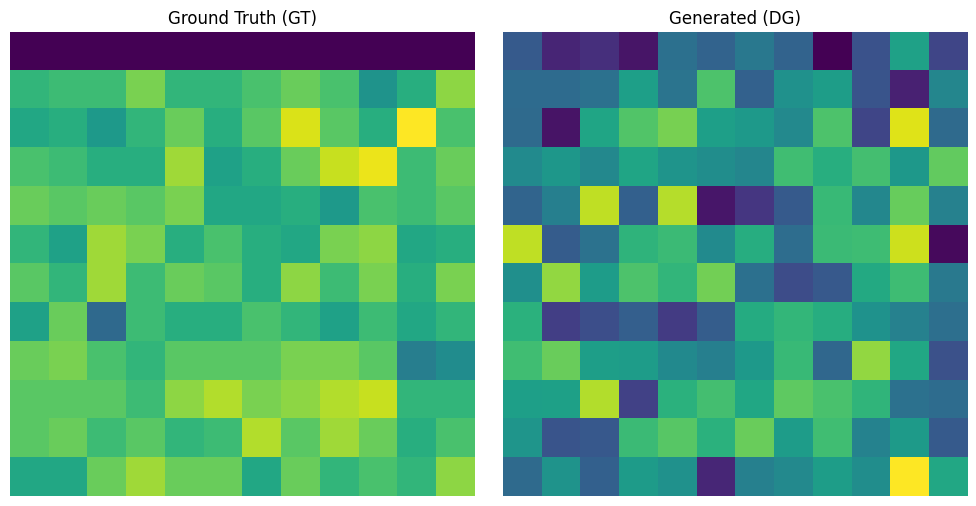

4387

In [6]:
 # get the first image with slice 0
img_gt = data_gt[0, 0, :, :, 0]
img_dg = data_dg[0, 0, :, :, 0]

print(img_gt.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gt)
plt.title("Ground Truth (GT)")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(img_dg)
plt.title("Generated (DG)")
plt.axis('off')

plt.tight_layout()
plt.show()

import gc
del gt
del degraded
gc.collect()

### Dataset

In [7]:
class VolumeDataset(Dataset):
    def __init__(self, data_gt, data_dg):
        self.data_gt = data_gt
        self.data_dg = data_dg

        assert len(data_gt) == len(data_dg), "GT und DG müssen gleich lang sein"

    def __len__(self):
        return len(self.data_gt)

    def __getitem__(self, idx):
        gt = self.data_gt[idx].astype(np.float32)
        dg = self.data_dg[idx].astype(np.float32)

        # numpy → torch
        gt = torch.from_numpy(gt)
        dg = torch.from_numpy(dg)

        return dg, gt   # input, target

### Normalisierung

In [8]:
print("Normalisiere Daten...")
data_gt_norm = np.array([(v - v.min()) / (v.max() - v.min() + 1e-8) for v in data_gt])
data_dg_norm = np.array([(v - v.min()) / (v.max() - v.min() + 1e-8) for v in data_dg])

Normalisiere Daten...


### Dataset + Dataloader

In [9]:
dataset = VolumeDataset(data_gt_norm, data_dg_norm)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False, # da später rekonstruktion zu ganzem bild!
    num_workers=0,
    pin_memory=False
)

# garbage collector
import gc
gc.collect()

0

###  3D CNN

In [10]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.bn = nn.BatchNorm3d(channels)
        self.conv = nn.Conv3d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):
        x = self.bn(x)
        x = self.conv(x)
        x = F.relu(x)
        return x


class CNN3D(nn.Module):
    def __init__(self):
        super().__init__()

        # First block: input -> 64 channels
        self.first = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 7 repeated blocks
        self.blocks = nn.Sequential(
            *[ConvBlock(64) for _ in range(7)]
        )

        # Last block (no activation)
        self.last = nn.Sequential(
            nn.BatchNorm3d(64),
            nn.Conv3d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.blocks(x)
        x = self.last(x)
        return x

In [11]:
# loss function
criterion = nn.MSELoss()

In [12]:
#optimizer
model = CNN3D()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [13]:
#training setup
num_epochs = 20

In [ ]:
#training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Starting epochs...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for dg, gt in dataloader:
        # print(dg.shape)
        # print(gt.shape)
    
        dg = dg.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()

        output = model(dg)

        loss = criterion(output, gt)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Starting epochs...
Epoch 1/20, Loss: 503.7141
Epoch 2/20, Loss: 316.4019
Epoch 3/20, Loss: 276.8392
Epoch 4/20, Loss: 255.3605
Epoch 5/20, Loss: 242.5554
Epoch 6/20, Loss: 234.2452
Epoch 7/20, Loss: 227.9600
Epoch 8/20, Loss: 223.4974
Epoch 9/20, Loss: 218.0063
Epoch 10/20, Loss: 213.7514
Epoch 11/20, Loss: 210.7223
Epoch 12/20, Loss: 208.7571
Epoch 13/20, Loss: 206.1214
Epoch 14/20, Loss: 203.6704
Epoch 15/20, Loss: 201.5936
Epoch 16/20, Loss: 199.8961
Epoch 17/20, Loss: 198.2049
Epoch 18/20, Loss: 196.8026


### Non-Local-Means filter (NLM)

In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma

def nlm_3d(cnn_output, h=0.8, patch_size=5, patch_distance=6):
    """
    cnn_output: (1, X, Y, Z) or (X, Y, Z)
    returns refined volume
    """

    if cnn_output.ndim == 4:
        cnn_output = cnn_output[0]

    X, Y, Z = cnn_output.shape
    result = np.zeros_like(cnn_output)

    for z in range(Z):
        slice_img = cnn_output[:, :, z]

        sigma_est = np.mean(estimate_sigma(slice_img, channel_axis=None))

        nlm = denoise_nl_means(
            slice_img,
            h=h * sigma_est,
            fast_mode=True,
            patch_size=patch_size,
            patch_distance=patch_distance,
            channel_axis=None
        )

        result[:, :, z] = nlm

    return result

In [ ]:
model.eval()

with torch.no_grad():
    dg = dg.to(device)

    cnn_out = model(dg)   # (B,1,12,12,12)

    cnn_out_np = cnn_out.cpu().numpy()

    refined_outputs = []

    for i in range(cnn_out_np.shape[0]):
        refined = nlm_3d(cnn_out_np[i])
        refined_outputs.append(refined)

    refined_outputs = np.array(refined_outputs)

### Visualisierungen

siehe data prep: noise-only differences, resolution-only differences (difference map)

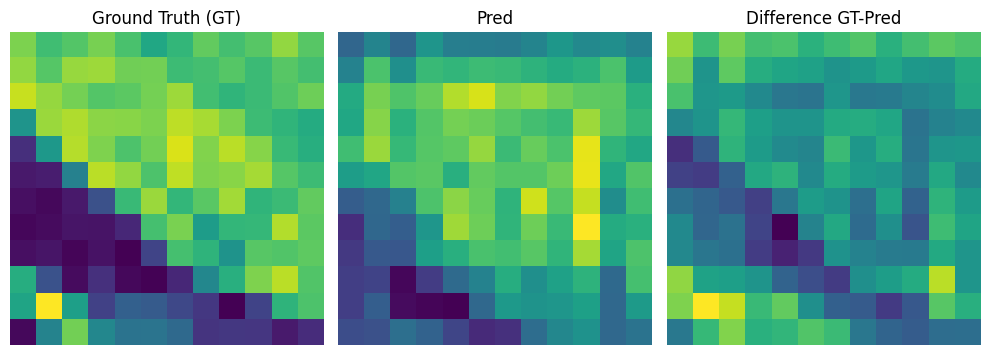

In [ ]:
# GT vs. Prediction + Difference Map (Prediction, GT)
# noise only
dg_batch0, gt_batch0 = next(iter(dataloader))


gt_batch0 = gt_batch0[0, 0, :, :, 0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(gt_batch0)
plt.title("Ground Truth (GT)")
plt.axis('off')

pred_dg = model(dg_batch0).detach().cpu()

pred_dg = pred_dg[0, 0, :, :, 0]
plt.subplot(1, 3, 2)
plt.imshow(pred_dg)
plt.title("Pred")
plt.axis('off')


difference_map = gt_batch0 - pred_dg
plt.subplot(1, 3, 3)
plt.imshow(difference_map)
plt.title("Difference GT-Pred")
plt.axis('off')


plt.tight_layout()
plt.show()
 # Visualisierung sieht schlecht aus, Modell ist ja auch noch nicht trainiert zum jetzigen Stand
 # Dataloader enthält Shuffle=True, deswegen immer zufälliger neuer 1. Batch

# SNR Berechnung auf Prediction und Ground Truth

In [ ]:
from skimage.metrics import peak_signal_noise_ratio


gt_batch0 = gt_batch0.numpy()
pred_dg = pred_dg.numpy()

dg_batch0 = dg_batch0[0, 0, :, :, 0].numpy()

psnr_gt_dg = peak_signal_noise_ratio(gt_batch0, dg_batch0, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_dg}")

psnr_gt_pred = peak_signal_noise_ratio(gt_batch0, pred_dg, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_pred}")

PSNR of 18.638075383174982
PSNR of 10.481100557813575


## Rekonstruktion 3D Bilder

für ground truth vorerst

In [ ]:
def rebuild_3d(patches, original_shape, patch_size=12, stride=12):
    """
    patches: Die extrahierten Patches für EINEN Zeitschritt (N, 12, 12, 12)
    original_shape: Die Form des ursprünglichen 3D-Bildes (X, Y, Z)
    """
    x, y, z = original_shape
    # Leeres Volumen mit Nullen erstellen
    reconstructed = np.zeros((x, y, z), dtype=patches.dtype)
    
    patch_idx = 0
    
    # Die gleichen Schleifen wie beim Splitten durchlaufen
    for i in range(0, x - patch_size + 1, stride):
        for j in range(0, y - patch_size + 1, stride):
            for k in range(0, z - patch_size + 1, stride):
                
                # Den aktuellen Patch an die richtige Stelle setzen
                reconstructed[i:i+patch_size, 
                              j:j+patch_size, 
                              k:k+patch_size] = patches[patch_idx]
                
                patch_idx += 1
                
    return reconstructed

In [ ]:
# 1. Bestimme, wie viele Patches ein einzelnes 3D-Volumen hat
# (Das ist all_chunks_gt.shape[1] aus deinem vorherigen Code)
patches_per_timestep = all_chunks_gt.shape[1]
print(patches_per_timestep)

num_timesteps = all_chunks_gt.shape[0]

print(num_timesteps)

original_3d_shape = volume_gt.shape[:3] # (X, Y, Z)

print(original_3d_shape)


# Angenommen 'denoised_data' sind deine bearbeiteten Patches in Shape (Gesamt, 1, 12, 12, 12)
# Wir entfernen zuerst die Kanal-Dimension
denoised_data = data_gt.squeeze(1) 

reconstructed_volume_4d = []

for t in range(num_timesteps):
    # Extrahiere die Patches für diesen spezifischen Zeitschritt
    start = t * patches_per_timestep
    end = start + patches_per_timestep
    current_time_patches = denoised_data[start:end]
    
    # Rekonstruiere das 3D-Bild
    img_3d = rebuild_3d(current_time_patches, original_3d_shape)
    reconstructed_volume_4d.append(img_3d)

# Wieder zu 4D zusammenfügen (X, Y, Z, Time)
final_volume = np.stack(reconstructed_volume_4d, axis=-1)

print(final_volume.shape) # Sollte wieder der Ursprungsform entsprechen

700
262
(128, 128, 84)
(128, 128, 84, 262)


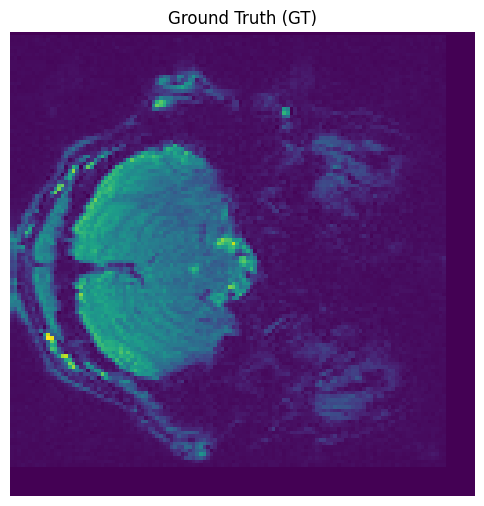

In [ ]:

visualization = final_volume[:, :, 0, 0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(visualization)
plt.title("Ground Truth (GT)")
plt.axis('off')

plt.tight_layout()
plt.show()
